# Sentence Memorability: Experimental Analysis

## Background & Research Context

This notebook presents a comprehensive analysis of a **continuous recognition memory experiment** investigating how sentence memorability is affected by the memorability of constituent words and syntactic voice.

### Relevant Literature
- **Shepard (1967)** — Recognition memory for words, sentences, and pictures ([link](https://www.sciencedirect.com/science/article/abs/pii/S0022537171800105))
- **Begg & Paivio (1969)** — Concreteness and imagery in sentence meaning ([link](https://www.sciencedirect.com/science/article/abs/pii/S0022537168800222))
- **Brockway, Chmielewski & Cofer (1974)** — Remembering prose ([link](https://www.sciencedirect.com/science/article/abs/pii/S002253717380060X))

### Experiment Summary
Simple **Subject–Verb–Object (S–V–O)** sentences were generated by systematically varying the memorability of the subject and object nouns. High- (H) and low- (L) memorability nouns were drawn from established word memorability norms; verbs were from a fixed set of medium-concreteness action verbs. This yielded **four sentence types**: HH, HL, LH, LL. Each sentence also has Active and Passive voice forms, yielding **8 conditions** total (4 × 2). The experiment uses a **continuous recognition paradigm** — each participant sees 48 target sentences across 3 blocks.

### Research Hypotheses
1. **H1**: Sentences with higher-memorability nouns (HH) will show higher corrected memorability scores than those with lower-memorability nouns (LL).
2. **H2**: Intermediate conditions (HL, LH) will fall between HH and LL, demonstrating noun-level memorability composition.
3. **H3**: Sentence voice (Active vs Passive) may modulate recognition memory performance.

### Planned Analyses
- **Corrected memorability scores** (Hit Rate − False Alarm Rate) per condition
- **Kruskal-Wallis H test** (non-parametric omnibus) across conditions
- **Dunn's post-hoc test** with **Bonferroni correction** for pairwise comparisons
- **Mann-Whitney U test** for voice effect
- Exploratory: Signal detection ($d'$, criterion $c$), block effects, reaction times

### Exclusion Criteria
Blocks failing the validation test are excluded:
$$\text{Correct Validation IRs} > \frac{\text{Wrong IRs}}{2} + \text{Missed Validation IRs}$$

## 1. Import Required Libraries

In [31]:
import csv
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from itertools import combinations
import scikit_posthocs as sp

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load and Concatenate Participant Log Files

Each `.log` file in `NewLogsAnonymized/` is one participant's complete experimental log (CSV format). We load all files, tag each with the participant ID (from the filename), and concatenate into a single master DataFrame.

In [32]:
LOGDIR = os.path.join(os.getcwd(), 'NewLogsAnonymized')
files = sorted(glob.glob(os.path.join(LOGDIR, '*.log')))

all_dfs = []
for filepath in files:
    pid = os.path.basename(filepath).replace('.log', '')
    df_p = pd.read_csv(filepath, encoding='utf-8-sig')
    df_p['pid'] = pid
    all_dfs.append(df_p)

df_raw = pd.concat(all_dfs, ignore_index=True)
print(f"Loaded {len(files)} participant log files")
print(f"Total rows: {len(df_raw):,}")
print(f"Columns: {list(df_raw.columns)}")

Loaded 114 participant log files
Total rows: 81,329
Columns: ['participant_ID', 'Timestamp', 'Event', 'Stimulus', 'isTarget', 'isValidation', 'isRepeat', 'Button', 'Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR', 'CR_IR', 'CR_WR', 'pid']


## 3. Dataset Structure Exploration

### Column Descriptions

| Column | Description |
|---|---|
| `participant_ID` | Anonymized numeric participant ID |
| `Timestamp` | Event time in milliseconds |
| `Event` | Event type: `Sentence shown`, `IR pressed`, `WR pressed`, `Missed`, `Validation IR pressed`, `Validation Wrong IR pressed`, `gap_time`, `Rest Phase started`, and practice variants |
| `Stimulus` | Sentence ID encoding condition, number, and voice (e.g., `HH_103_A` = HH condition, sentence 103, Active voice) |
| `isTarget` | `true` if the sentence is a target (will appear twice); blank for fillers |
| `isValidation` | `true` if this is a validation/attention-check sentence |
| `isRepeat` | `true` if this is the second (recognition) presentation |
| `Button` | Response key: `Spacebar` (IR), `Yes`/`No` (WR), `GapTime_XXXX` (ISI), `Rest` |
| `Accuracy IR` | 1 = correct IR response, 0 = incorrect |
| `Accuracy WR` | 1 = correct WR response, 0 = incorrect |
| `Reaction_time_IR` | Milliseconds from sentence onset to Spacebar press |
| `Reaction_time_WR` | Milliseconds from WR prompt to Yes/No click |
| `CR_IR` / `CR_WR` | Cumulative recall columns (reserved, currently empty) |

### Stimulus Naming Convention

| Prefix | Meaning | Role |
|---|---|---|
| `HH` | High-memorability Subject × High-memorability Object | **Target** |
| `HVL` | High Subject × Low Object (= HL condition) | **Target** |
| `LVH` | Low Subject × High Object (= LH condition) | **Target** |
| `LVL` | Low Subject × Low Object (= LL condition) | **Target** |
| `HL` | Filler sentences (High-Low, shown once only) | **Filler** (false alarm baseline) |
| `HF` | High-Frequency validation sentences | **Validation** (attention check) |

The `_A` suffix = Active voice, `_P` suffix = Passive voice. Voice at encoding and test is fully counterbalanced (A→A, A→P, P→A, P→P).

In [33]:
# Basic shape and dtypes
print("Shape:", df_raw.shape)
print("\nData types:")
print(df_raw.dtypes)
print("\nFirst 5 rows:")
df_raw.head()

Shape: (81329, 15)

Data types:
participant_ID        int64
Timestamp             int64
Event                object
Stimulus             object
isTarget             object
isValidation         object
isRepeat             object
Button               object
Accuracy IR         float64
Accuracy WR         float64
Reaction_time_IR    float64
Reaction_time_WR    float64
CR_IR               float64
CR_WR               float64
pid                  object
dtype: object

First 5 rows:


,participant_ID,Timestamp,Event,Stimulus,isTarget,isValidation,isRepeat,Button,Accuracy IR,Accuracy WR,Reaction_time_IR,Reaction_time_WR,CR_IR,CR_WR,pid
0,232,1770218920752,Practice Sentence shown,HH_112_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232
1,232,1770218923564,Practice IR pressed,HH_112_A,True,NaN,NaN,Spacebar,0.0,NaN,2812.0,NaN,NaN,NaN,232
2,232,1770218924911,Practice Sentence shown,HL_16_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232
3,232,1770218930413,Practice Sentence shown,HH_116_A,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232
4,232,1770218935915,Practice Sentence shown,HL_62_A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,232


In [34]:
# Unique event types and their counts
print("Event type distribution:")
print(df_raw['Event'].value_counts().to_string())
print(f"\nUnique participants: {df_raw['pid'].nunique()}")

# Stimulus prefix distribution (across all data)
df_raw['stim_prefix'] = df_raw['Stimulus'].apply(lambda x: str(x).split('_')[0] if pd.notna(x) else None)
print("\nStimulus prefix counts (all events):")
print(df_raw['stim_prefix'].value_counts().to_string())

Event type distribution:
Event
Sentence shown                 25308
gap_time                       25308
IR pressed                      9857
WR pressed                      9857
Practice Sentence shown         3420
Validation IR pressed           3231
Validation Wrong IR pressed     2082
Practice IR pressed              994
Practice WR pressed              709
Rest Phase started               228
Validation Missed                189
Practice Missed                  146

Unique participants: 114

Stimulus prefix counts (all events):
stim_prefix
HF     29733
HH      8589
HVL     5335
LVH     5130
LVL     5077
HL      1923


## 4. Data Cleaning and Preprocessing

We:
1. Remove practice events (not part of the real experiment)
2. Parse stimulus IDs into condition, sentence number, and voice
3. Map internal condition codes to the 4 research conditions (HH, HL, LH, LL)
4. Convert accuracy and reaction time columns to proper numeric types
5. Assign block numbers based on `Rest Phase started` events

In [35]:
# Remove practice events
df = df_raw[~df_raw['Event'].str.startswith('Practice', na=False)].copy()
print(f"Rows after removing practice: {len(df):,} (removed {len(df_raw) - len(df):,} practice rows)")

# Parse stimulus ID into components
def parse_stimulus(stim):
    """Parse stimulus string like 'HH_103_A' into (prefix, number, voice)."""
    if pd.isna(stim):
        return None, None, None
    parts = str(stim).split('_')
    if len(parts) >= 3:
        return parts[0], parts[1], parts[2]
    return parts[0] if len(parts) > 0 else None, None, None

df[['stim_prefix', 'sent_num', 'voice']] = df['Stimulus'].apply(
    lambda x: pd.Series(parse_stimulus(x)))

# Map internal codes to research condition labels
COND_MAP = {'HH': 'HH', 'HVL': 'HL', 'LVH': 'LH', 'LVL': 'LL'}
df['condition'] = df['stim_prefix'].map(COND_MAP)

# Extract subject and object memorability as separate factors
SUBJ_MEMO = {'HH': 'High', 'HL': 'High', 'LH': 'Low', 'LL': 'Low'}
OBJ_MEMO = {'HH': 'High', 'HL': 'Low', 'LH': 'High', 'LL': 'Low'}
df['subject_memorability'] = df['condition'].map(SUBJ_MEMO)
df['object_memorability'] = df['condition'].map(OBJ_MEMO)

# Voice label
df['voice_label'] = df['voice'].map({'A': 'Active', 'P': 'Passive'})

# Convert numeric columns
for col in ['Accuracy IR', 'Accuracy WR', 'Reaction_time_IR', 'Reaction_time_WR']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Standardize boolean columns
df['is_target'] = (df['isTarget'] == 'true') | (df['isTarget'] == True)
df['is_repeat'] = (df['isRepeat'] == 'true') | (df['isRepeat'] == True)
df['is_validation'] = (df['isValidation'] == 'true') | (df['isValidation'] == True)

# Assign block numbers per participant (based on Rest Phase started)
df['block'] = 0
for pid in df['pid'].unique():
    mask = df['pid'] == pid
    rest_mask = mask & (df['Event'] == 'Rest Phase started')
    rest_indices = df[rest_mask].index.tolist()
    pid_indices = df[mask].index
    block_num = 0
    for idx in pid_indices:
        if idx in rest_indices:
            block_num += 1
        df.loc[idx, 'block'] = block_num

print(f"Cleaned DataFrame shape: {df.shape}")
print(f"Conditions present: {sorted(df['condition'].dropna().unique())}")
print(f"\nSample of cleaned data:")
df[df['Event'] == 'Sentence shown'][['pid', 'Event', 'Stimulus', 'condition', 
    'voice_label', 'is_target', 'is_repeat', 'is_validation', 'block']].head(10)

Rows after removing practice: 76,060 (removed 5,269 practice rows)
Cleaned DataFrame shape: (76060, 26)
Conditions present: ['HH', 'HL', 'LH', 'LL']

Sample of cleaned data:


,pid,Event,Stimulus,condition,voice_label,is_target,is_repeat,is_validation,block
62,232,Sentence shown,HF_29_A,NaN,Active,False,False,False,0
64,232,Sentence shown,HF_9_A,NaN,Active,False,False,False,0
66,232,Sentence shown,HF_24_A,NaN,Active,False,False,False,0
68,232,Sentence shown,HF_1_A,NaN,Active,False,False,False,0
70,232,Sentence shown,HF_7_A,NaN,Active,False,False,False,0
72,232,Sentence shown,HF_28_A,NaN,Active,False,False,False,0
74,232,Sentence shown,HF_11_A,NaN,Active,False,False,False,0
76,232,Sentence shown,HF_2_A,NaN,Active,False,False,False,0
78,232,Sentence shown,HF_4_A,NaN,Active,False,False,False,0
83,232,Sentence shown,HF_32_A,NaN,Active,False,False,False,0


## 5. Apply Exclusion Criteria (Block-Level Validation Filter)

For each participant's each block, we compute:
1. **Correct Validation IRs**: correct Spacebar presses on validation sentences
2. **Wrong IRs**: incorrect presses on validation trials (`Validation Wrong IR pressed`)
3. **Missed Validation IRs**: validation sentences that were shown but got no response

A block is **retained** only if:
$$\text{Correct Validation IRs} > \frac{\text{Wrong IRs}}{2} + \text{Missed Validation IRs}$$

In [36]:
validation_records = []

for pid in df['pid'].unique():
    df_pid = df[df['pid'] == pid]
    for block in df_pid['block'].unique():
        df_block = df_pid[df_pid['block'] == block]
        
        # Correct validation IRs
        correct_val = len(df_block[(df_block['Event'] == 'Validation IR pressed') & 
                                    (df_block['Accuracy IR'] == 1)])
        # Wrong validation IRs
        wrong_val = len(df_block[df_block['Event'] == 'Validation Wrong IR pressed'])
        
        # Validation sentences shown in this block
        val_shown = len(df_block[(df_block['is_validation']) & 
                                  (df_block['Event'] == 'Sentence shown')])
        
        # Missed = shown - correct - wrong
        missed_val = max(0, val_shown - correct_val - wrong_val)
        
        # Validation criterion
        passes = correct_val > (wrong_val / 2) + missed_val
        
        validation_records.append({
            'pid': pid, 'block': block,
            'correct_val': correct_val, 'wrong_val': wrong_val,
            'missed_val': missed_val, 'val_shown': val_shown,
            'passes': passes
        })

df_val = pd.DataFrame(validation_records)

total_blocks = len(df_val)
excluded_blocks = len(df_val[~df_val['passes']])
excluded_pids = df_val.groupby('pid')['passes'].any()
fully_excluded = (~excluded_pids).sum()

print(f"Total blocks assessed: {total_blocks}")
print(f"Excluded blocks: {excluded_blocks} ({100*excluded_blocks/total_blocks:.1f}%)")
print(f"Fully excluded participants (all blocks failed): {fully_excluded}")
print(f"Participants with ≥1 valid block: {excluded_pids.sum()}")

# Show exclusion summary
print("\nExclusion summary by participant (showing excluded blocks only):")
excluded_detail = df_val[~df_val['passes']][['pid', 'block', 'correct_val', 'wrong_val', 'missed_val']]
if len(excluded_detail) > 0:
    display(excluded_detail)
else:
    print("  No blocks were excluded.")

# Create set of valid (pid, block) pairs for filtering
valid_blocks = set(zip(df_val[df_val['passes']]['pid'], df_val[df_val['passes']]['block']))
df['valid_block'] = df.apply(lambda r: (r['pid'], r['block']) in valid_blocks, axis=1)
df_valid = df[df['valid_block']].copy()
print(f"\nRows after exclusion: {len(df_valid):,} (removed {len(df) - len(df_valid):,})")
print(f"Valid participants: {df_valid['pid'].nunique()}")

Total blocks assessed: 342
Excluded blocks: 10 (2.9%)
Fully excluded participants (all blocks failed): 1
Participants with ≥1 valid block: 113

Exclusion summary by participant (showing excluded blocks only):


,pid,block,correct_val,wrong_val,missed_val
81,271,0,10,25,0
82,271,1,10,21,0
83,271,2,10,27,0
126,294,0,9,18,0
136,297,1,10,20,0
142,299,1,3,9,0
143,299,2,3,2,5
235,346,1,9,18,0
268,367,1,10,20,0
285,373,0,10,20,0



Rows after exclusion: 73,503 (removed 2,557)
Valid participants: 113


## 6. Compute Corrected Memorability Scores

The **corrected memorability score** for each participant × condition is:

$$\text{Corrected Score} = \text{Hit Rate} - \text{False Alarm Rate}$$

Where:
- **Hit Rate** = proportion of correctly recognized repeat targets (IR hits / total repeat targets shown) per condition
- **False Alarm Rate** = proportion of IR presses on non-repeat, non-validation sentences (computed per participant across all conditions)

In [37]:
# --- Hit Rate per participant × condition ---
# Targets shown (repeat presentations from valid blocks, non-validation)
targets_shown = df_valid[(df_valid['Event'] == 'Sentence shown') & 
                          df_valid['is_repeat'] & ~df_valid['is_validation']].copy()
targets_per_pc = targets_shown.groupby(['pid', 'condition']).size().reset_index(name='n_targets')

# IR hits on repeats (non-validation)
ir_hits = df_valid[(df_valid['Event'] == 'IR pressed') & 
                    df_valid['is_repeat'] & ~df_valid['is_validation']].copy()
ir_hit_counts = ir_hits.groupby(['pid', 'condition'])['Accuracy IR'].agg(
    ir_hits='sum', ir_responses='count').reset_index()

hit_df = targets_per_pc.merge(ir_hit_counts, on=['pid', 'condition'], how='left')
hit_df['ir_hits'] = hit_df['ir_hits'].fillna(0)
hit_df['hit_rate'] = hit_df['ir_hits'] / hit_df['n_targets']

# --- False Alarm Rate per participant ---
# Non-repeat, non-validation sentences shown
nonrepeat_shown = df_valid[(df_valid['Event'] == 'Sentence shown') & 
                            ~df_valid['is_repeat'] & ~df_valid['is_validation']]
nonrepeat_per_p = nonrepeat_shown.groupby('pid').size().reset_index(name='n_nonrepeat')

# False alarm IR presses
ir_fa = df_valid[(df_valid['Event'] == 'IR pressed') & 
                  ~df_valid['is_repeat'] & ~df_valid['is_validation']]
fa_per_p = ir_fa.groupby('pid').size().reset_index(name='n_fa')

fa_df = nonrepeat_per_p.merge(fa_per_p, on='pid', how='left')
fa_df['n_fa'] = fa_df['n_fa'].fillna(0)
fa_df['fa_rate'] = fa_df['n_fa'] / fa_df['n_nonrepeat']

# --- Corrected Score = Hit Rate - FA Rate ---
corrected_df = hit_df.merge(fa_df[['pid', 'fa_rate']], on='pid', how='left')
corrected_df['corrected_score'] = corrected_df['hit_rate'] - corrected_df['fa_rate']

# Add factor labels
corrected_df['subject_memorability'] = corrected_df['condition'].map(SUBJ_MEMO)
corrected_df['object_memorability'] = corrected_df['condition'].map(OBJ_MEMO)

print(f"Corrected scores computed for {corrected_df['pid'].nunique()} participants × {corrected_df['condition'].nunique()} conditions")
print(f"Total score records: {len(corrected_df)}")
corrected_df[['pid', 'condition', 'n_targets', 'ir_hits', 'hit_rate', 'fa_rate', 'corrected_score']].head(12)

Corrected scores computed for 113 participants × 4 conditions
Total score records: 452


,pid,condition,n_targets,ir_hits,hit_rate,fa_rate,corrected_score
0,232,HH,12,12.0,1.000000,0.111111,0.888889
1,232,HL,12,12.0,1.000000,0.111111,0.888889
2,232,LH,12,11.0,0.916667,0.111111,0.805556
3,232,LL,12,12.0,1.000000,0.111111,0.888889
4,235,HH,12,11.0,0.916667,0.152778,0.763889
5,235,HL,12,10.0,0.833333,0.152778,0.680556
6,235,LH,12,8.0,0.666667,0.152778,0.513889
7,235,LL,12,7.0,0.583333,0.152778,0.430556
8,236,HH,12,12.0,1.000000,0.104167,0.895833
9,236,HL,12,11.0,0.916667,0.104167,0.812500


## 7. Descriptive Statistics by Condition

In [38]:
cond_order = ['HH', 'HL', 'LH', 'LL']

# Descriptive statistics table
desc_stats = corrected_df.groupby('condition')['corrected_score'].agg(
    Mean='mean', Median='median', SD='std', 
    SE=lambda x: x.std()/np.sqrt(len(x)),
    N='count'
).loc[cond_order]

desc_stats['95% CI Lower'] = desc_stats['Mean'] - 1.96 * desc_stats['SE']
desc_stats['95% CI Upper'] = desc_stats['Mean'] + 1.96 * desc_stats['SE']

print("=" * 70)
print("CORRECTED IR MEMORABILITY SCORES BY CONDITION")
print("=" * 70)
display(desc_stats.round(4))

# Also show hit rate and FA rate summaries
print("\nHit Rates by Condition:")
hit_summary = corrected_df.groupby('condition')['hit_rate'].agg(['mean', 'std']).loc[cond_order]
hit_summary.columns = ['Mean Hit Rate', 'SD']
display(hit_summary.round(4))

print(f"\nOverall False Alarm Rate: {fa_df['fa_rate'].mean():.4f} ± {fa_df['fa_rate'].std():.4f}")

CORRECTED IR MEMORABILITY SCORES BY CONDITION


,Mean,Median,SD,SE,N,95% CI Lower,95% CI Upper
condition,,,,,,,
HH,0.7239,0.7708,0.1757,0.0165,113,0.6915,0.7563
HL,0.7247,0.7500,0.1765,0.0166,113,0.6921,0.7572
LH,0.7155,0.7569,0.1794,0.0169,113,0.6824,0.7485
LL,0.6657,0.6875,0.1836,0.0173,113,0.6318,0.6995



Hit Rates by Condition:


,Mean Hit Rate,SD
condition,,
HH,0.8459,0.1674
HL,0.8466,0.1745
LH,0.8374,0.1728
LL,0.7876,0.1885



Overall False Alarm Rate: 0.1219 ± 0.0784


## 8. Visualize Hit Rates and False Alarm Rates

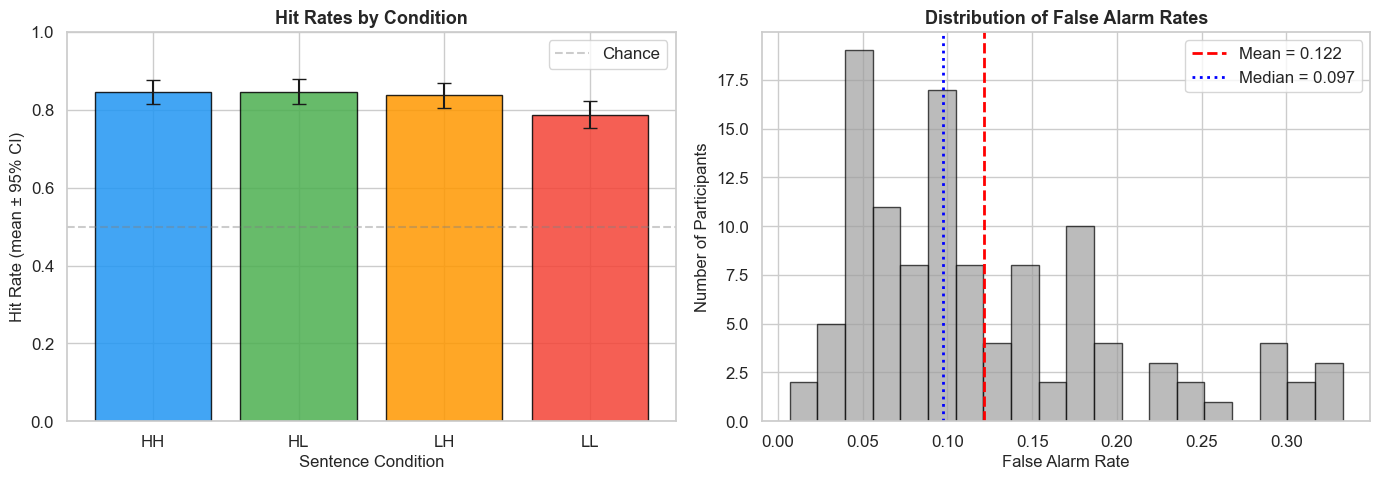

In [39]:
palette = {'HH': '#2196F3', 'HL': '#4CAF50', 'LH': '#FF9800', 'LL': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hit rates by condition
ax = axes[0]
hit_means = corrected_df.groupby('condition')['hit_rate'].agg(['mean', 'sem']).loc[cond_order]
bars = ax.bar(cond_order, hit_means['mean'], yerr=hit_means['sem']*1.96, capsize=5,
              color=[palette[c] for c in cond_order], edgecolor='black', alpha=0.85)
ax.set_xlabel('Sentence Condition', fontsize=12)
ax.set_ylabel('Hit Rate (mean ± 95% CI)', fontsize=12)
ax.set_title('Hit Rates by Condition', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Chance')
ax.legend()

# FA rate distribution
ax = axes[1]
ax.hist(fa_df['fa_rate'], bins=20, color='#9E9E9E', edgecolor='black', alpha=0.7)
ax.axvline(fa_df['fa_rate'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean = {fa_df['fa_rate'].mean():.3f}")
ax.axvline(fa_df['fa_rate'].median(), color='blue', linestyle=':', linewidth=2,
           label=f"Median = {fa_df['fa_rate'].median():.3f}")
ax.set_xlabel('False Alarm Rate', fontsize=12)
ax.set_ylabel('Number of Participants', fontsize=12)
ax.set_title('Distribution of False Alarm Rates', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## 9. Visualize Corrected Memorability Scores Across Conditions

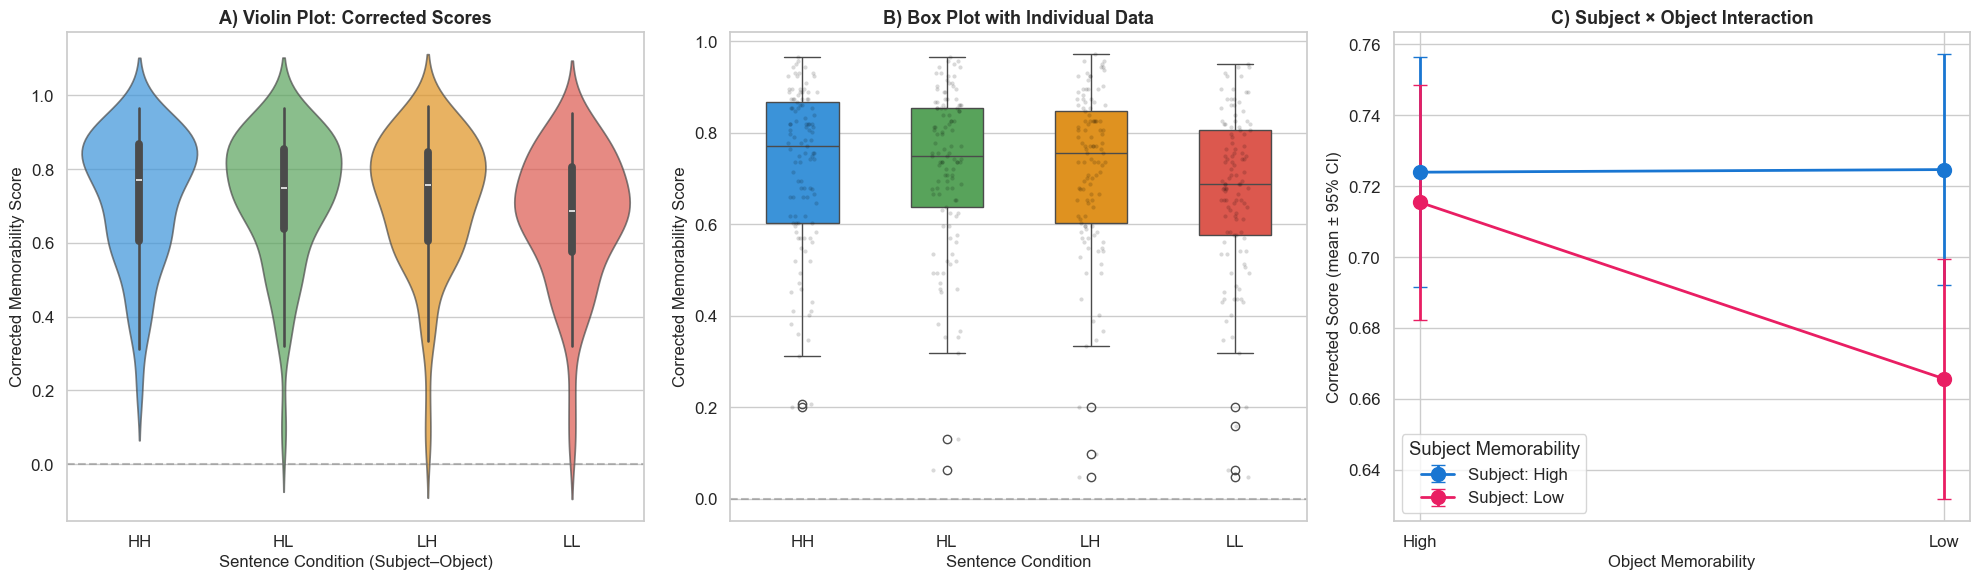

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# a) Violin + box plot
ax = axes[0]
sns.violinplot(data=corrected_df, x='condition', y='corrected_score',
               order=cond_order, palette=palette, inner='box', alpha=0.7, ax=ax)
ax.set_xlabel('Sentence Condition (Subject–Object)', fontsize=12)
ax.set_ylabel('Corrected Memorability Score', fontsize=12)
ax.set_title('A) Violin Plot: Corrected Scores', fontsize=13, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# b) Box plot with individual points
ax = axes[1]
sns.boxplot(data=corrected_df, x='condition', y='corrected_score',
            order=cond_order, palette=palette, width=0.5, ax=ax)
sns.stripplot(data=corrected_df, x='condition', y='corrected_score',
              order=cond_order, color='black', alpha=0.15, size=3, jitter=True, ax=ax)
ax.set_xlabel('Sentence Condition', fontsize=12)
ax.set_ylabel('Corrected Memorability Score', fontsize=12)
ax.set_title('B) Box Plot with Individual Data', fontsize=13, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# c) Interaction plot: Subject × Object memorability
ax = axes[2]
interaction_data = corrected_df.groupby(['subject_memorability', 'object_memorability'])[
    'corrected_score'].agg(['mean', 'sem']).reset_index()
for subj in ['High', 'Low']:
    sub = interaction_data[interaction_data['subject_memorability'] == subj]
    color = '#1976D2' if subj == 'High' else '#E91E63'
    ax.errorbar(sub['object_memorability'], sub['mean'], yerr=sub['sem']*1.96,
                marker='o', markersize=10, linewidth=2, capsize=5, label=f'Subject: {subj}',
                color=color)
ax.set_xlabel('Object Memorability', fontsize=12)
ax.set_ylabel('Corrected Score (mean ± 95% CI)', fontsize=12)
ax.set_title('C) Subject × Object Interaction', fontsize=13, fontweight='bold')
ax.legend(title='Subject Memorability')

plt.tight_layout()
plt.show()

## 10. Normality Testing (Shapiro-Wilk)

Before running inferential tests, we check whether corrected memorability scores follow a normal distribution. This determines whether to use parametric (ANOVA) or non-parametric (Kruskal-Wallis) tests.

Shapiro-Wilk Normality Tests:


,Condition,W statistic,p-value,Normal?
0,HH,0.923956,0.000007,No
1,HL,0.914147,0.000002,No
2,LH,0.918656,0.000004,No
3,LL,0.940491,0.000077,No


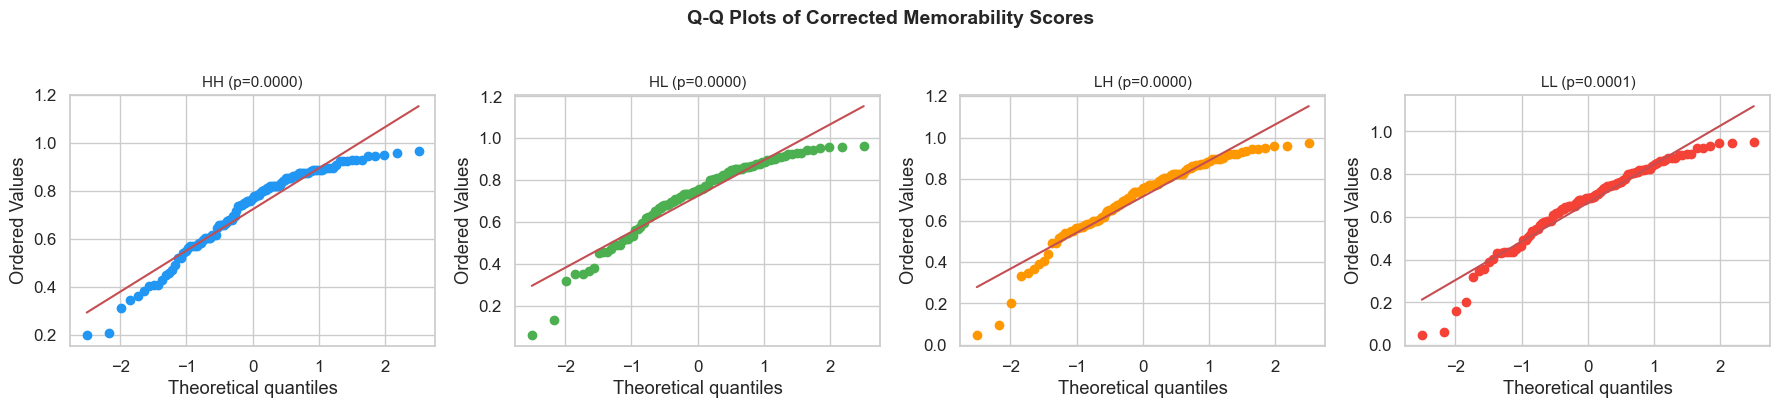


✓ All conditions show significant departures from normality (p < .05).
  → Non-parametric Kruskal-Wallis test is appropriate.


In [41]:
normality_results = []
for cond in cond_order:
    data = corrected_df[corrected_df['condition'] == cond]['corrected_score'].values
    w_stat, p_val = stats.shapiro(data)
    normality_results.append({
        'Condition': cond, 'W statistic': w_stat, 'p-value': p_val,
        'Normal?': 'Yes' if p_val >= 0.05 else 'No'
    })

df_norm = pd.DataFrame(normality_results)
print("Shapiro-Wilk Normality Tests:")
display(df_norm)

# Q-Q plots
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, cond in enumerate(cond_order):
    ax = axes[i]
    data = corrected_df[corrected_df['condition'] == cond]['corrected_score'].values
    stats.probplot(data, dist="norm", plot=ax)
    ax.set_title(f'{cond} (p={normality_results[i]["p-value"]:.4f})', fontsize=11)
    ax.get_lines()[0].set_color(palette[cond])
plt.suptitle('Q-Q Plots of Corrected Memorability Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✓ All conditions show significant departures from normality (p < .05).")
print("  → Non-parametric Kruskal-Wallis test is appropriate.")

## 11. Kruskal-Wallis Test: Effect of Sentence Type (HH, HL, LH, LL)

The primary analysis: does corrected memorability differ across the four noun-memorability conditions?

$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$$

Effect size: $\eta^2_H = \frac{H - k + 1}{N - k}$

In [42]:
groups = [corrected_df[corrected_df['condition'] == c]['corrected_score'].values for c in cond_order]
kw_stat, kw_p = stats.kruskal(*groups)

n_total = sum(len(g) for g in groups)
k = len(groups)
eta_sq = (kw_stat - k + 1) / (n_total - k)

print("=" * 60)
print("KRUSKAL-WALLIS TEST: Sentence Type Effect")
print("=" * 60)
print(f"  H({k-1}) = {kw_stat:.4f}")
print(f"  p = {kw_p:.6f}")
print(f"  Effect size η²_H = {eta_sq:.4f}")
print(f"  N = {n_total}")
print()
if kw_p < 0.05:
    print("  ★ SIGNIFICANT at α = 0.05")
    print("  → Corrected memorability scores differ across conditions.")
    print("  → Proceeding to post-hoc pairwise comparisons.")
else:
    print("  Not significant at α = 0.05")

KRUSKAL-WALLIS TEST: Sentence Type Effect
  H(3) = 10.0014
  p = 0.018554
  Effect size η²_H = 0.0156
  N = 452

  ★ SIGNIFICANT at α = 0.05
  → Corrected memorability scores differ across conditions.
  → Proceeding to post-hoc pairwise comparisons.


## 12. Kruskal-Wallis / Mann-Whitney U: Effect of Voice (Active vs Passive)

Testing whether the voice at the test presentation (Active vs Passive) affects corrected memorability. Since there are only 2 groups, we use the Mann-Whitney U test.

In [43]:
# Compute voice-level corrected scores
ir_hits_voice = df_valid[(df_valid['Event'] == 'IR pressed') & 
                          df_valid['is_repeat'] & ~df_valid['is_validation']].copy()
targets_voice = targets_shown.groupby(['pid', 'voice']).size().reset_index(name='n_shown')
voice_hit = ir_hits_voice.groupby(['pid', 'voice'])['Accuracy IR'].sum().reset_index(name='hits')

voice_df = targets_voice.merge(voice_hit, on=['pid', 'voice'], how='left')
voice_df['hits'] = voice_df['hits'].fillna(0)
voice_df['hit_rate'] = voice_df['hits'] / voice_df['n_shown']
voice_df = voice_df.merge(fa_df[['pid', 'fa_rate']], on='pid', how='left')
voice_df['corrected_score'] = voice_df['hit_rate'] - voice_df['fa_rate']
voice_df['voice_label'] = voice_df['voice'].map({'A': 'Active', 'P': 'Passive'})

# Descriptive
print("Voice Corrected Scores:")
voice_desc = voice_df.groupby('voice_label')['corrected_score'].agg(['mean', 'std', 'count'])
display(voice_desc.round(4))

# Mann-Whitney U test  
active = voice_df[voice_df['voice'] == 'A']['corrected_score'].values
passive = voice_df[voice_df['voice'] == 'P']['corrected_score'].values
mw_stat, mw_p = stats.mannwhitneyu(active, passive, alternative='two-sided')

n1, n2 = len(active), len(passive)
rank_biserial = 1 - (2 * mw_stat) / (n1 * n2)

print(f"\nMann-Whitney U Test: Active vs Passive Voice")
print(f"  U = {mw_stat:.2f}, p = {mw_p:.6f}")
print(f"  Rank-biserial r = {rank_biserial:.4f}")
if mw_p < 0.05:
    print("  ★ SIGNIFICANT at α = 0.05")
else:
    print("  ✗ NOT significant at α = 0.05")
    print("  → Voice at test does not significantly affect corrected memorability.")

Voice Corrected Scores:


,mean,std,count
voice_label,,,
Active,0.7016,0.1605,113
Passive,0.7132,0.1653,113



Mann-Whitney U Test: Active vs Passive Voice
  U = 6055.50, p = 0.503836
  Rank-biserial r = 0.0515
  ✗ NOT significant at α = 0.05
  → Voice at test does not significantly affect corrected memorability.


## 13. Post-Hoc Pairwise Comparisons: Dunn's Test with Bonferroni & Holm Corrections

Since the Kruskal-Wallis test was significant, we perform pairwise comparisons using **Dunn's test**. Two correction methods are applied:

1. **Bonferroni correction**: divides α by the number of comparisons ($\alpha_{adj} = 0.05 / 6 = 0.0083$). Very conservative — controls family-wise error rate (FWER).
2. **Holm's step-down correction**: a less conservative sequential method that also controls FWER but has more power.

With 4 conditions, there are $\binom{4}{2} = 6$ pairwise comparisons.

Dunn's Post-Hoc Test — Bonferroni-adjusted p-values:


,HH,HL,LH,LL
HH,1.000000,1.000000,1.000000,0.040809
HL,1.000000,1.000000,1.000000,0.043217
LH,1.000000,1.000000,1.000000,0.147538
LL,0.040809,0.043217,0.147538,1.000000



Dunn's Post-Hoc Test — Holm-adjusted p-values:


,HH,HL,LH,LL
HH,1.000000,1.000000,1.000000,0.040809
HL,1.000000,1.000000,1.000000,0.040809
LH,1.000000,1.000000,1.000000,0.098358
LL,0.040809,0.040809,0.098358,1.000000


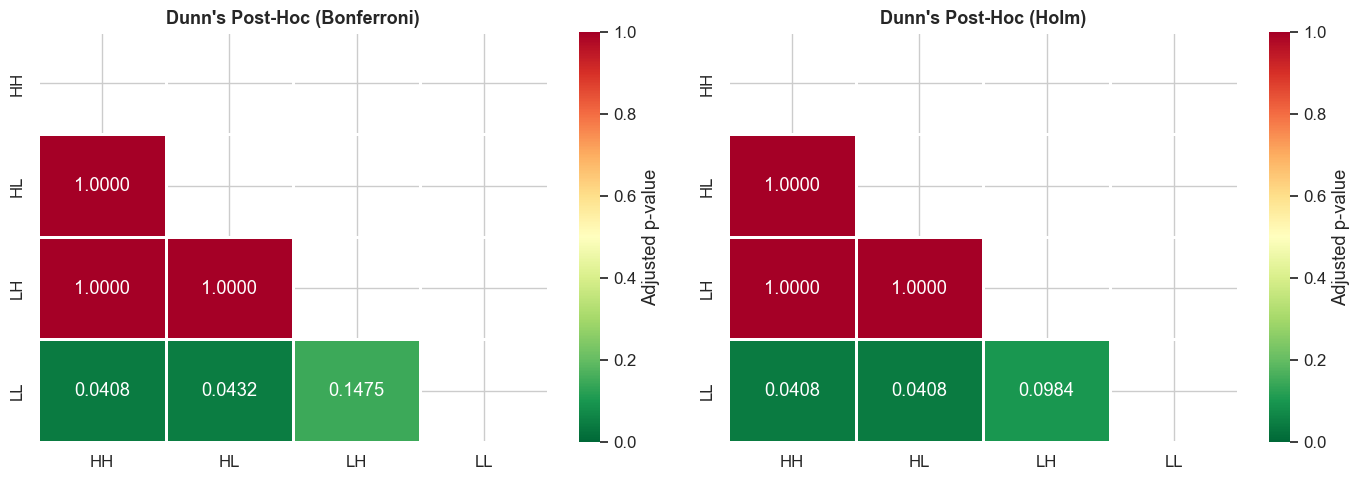


Significant pairwise comparisons (Bonferroni, p < .05):
  HH vs LL: p = 0.040809 *
  HL vs LL: p = 0.043217 *


In [44]:
# Dunn's test with Bonferroni correction
dunn_bonf = sp.posthoc_dunn(corrected_df, val_col='corrected_score',
                             group_col='condition', p_adjust='bonferroni')
dunn_bonf = dunn_bonf.loc[cond_order, cond_order]

print("Dunn's Post-Hoc Test — Bonferroni-adjusted p-values:")
display(dunn_bonf.round(6))

# Dunn's test with Holm correction
dunn_holm = sp.posthoc_dunn(corrected_df, val_col='corrected_score',
                             group_col='condition', p_adjust='holm')
dunn_holm = dunn_holm.loc[cond_order, cond_order]

print("\nDunn's Post-Hoc Test — Holm-adjusted p-values:")
display(dunn_holm.round(6))

# Heatmap visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in [(axes[0], dunn_bonf, 'Bonferroni'), (axes[1], dunn_holm, 'Holm')]:
    mask = np.triu(np.ones_like(data, dtype=bool))
    sns.heatmap(data, annot=True, fmt='.4f', cmap='RdYlGn_r',
                mask=mask, vmin=0, vmax=1, ax=ax, linewidths=1,
                cbar_kws={'label': 'Adjusted p-value'})
    ax.set_title(f"Dunn's Post-Hoc ({title})", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary of significant pairs
print("\nSignificant pairwise comparisons (Bonferroni, p < .05):")
for i in range(len(cond_order)):
    for j in range(i+1, len(cond_order)):
        p = dunn_bonf.iloc[i, j]
        if p < 0.05:
            print(f"  {cond_order[i]} vs {cond_order[j]}: p = {p:.6f} *")

## 14. Interaction Analysis: Word Memorability × Voice

Testing whether the full 8-group design (4 conditions × 2 voices) shows significant differences, and visualizing the Condition × Voice interaction.

Kruskal-Wallis Test: 8-group (Condition × Voice)
  H(7) = 14.0333, p = 0.050592
  ✗ NOT significant — no evidence for Condition × Voice interaction

Condition × Voice Corrected Scores:


mean     std
condition voice_label                
HH        Active       0.7144  0.1963
          Passive      0.7335  0.2033
HL        Active       0.7210  0.2028
          Passive      0.7284  0.2003
LH        Active       0.7151  0.1914
          Passive      0.7158  0.2140
LL        Active       0.6561  0.2344
          Passive      0.6753  0.2072

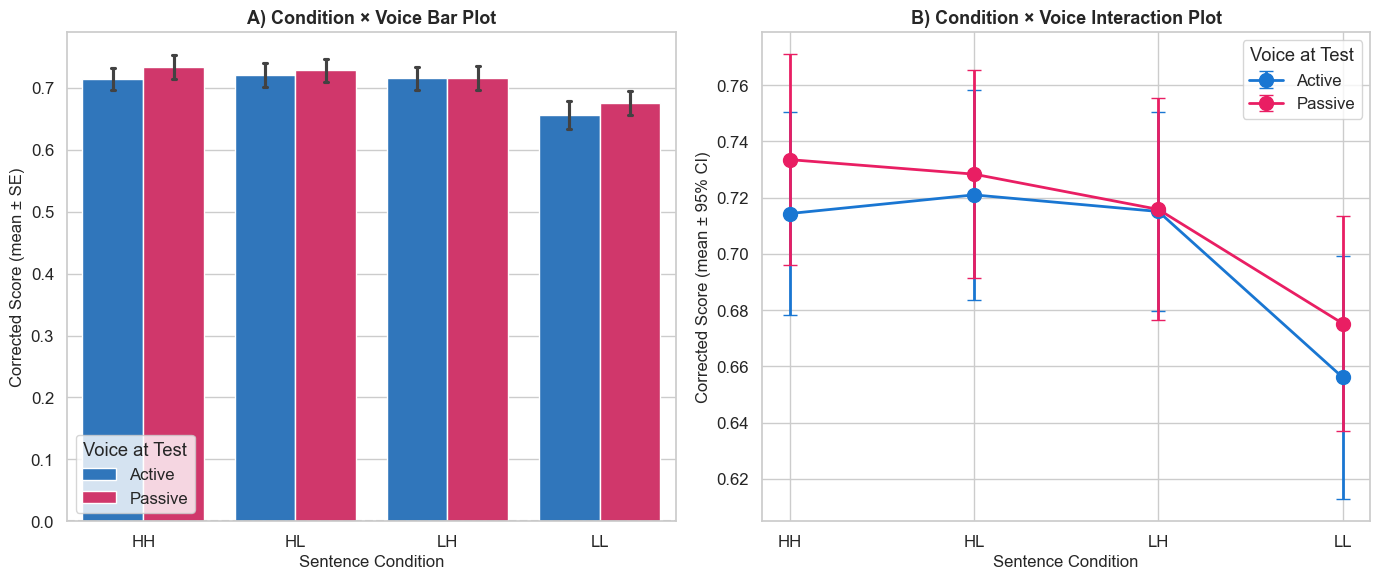

In [45]:
# Compute condition × voice scores
ir_cv = df_valid[(df_valid['Event'] == 'IR pressed') & 
                  df_valid['is_repeat'] & ~df_valid['is_validation']].copy()
tgt_cv = targets_shown.groupby(['pid', 'condition', 'voice']).size().reset_index(name='n_shown')
hit_cv = ir_cv.groupby(['pid', 'condition', 'voice'])['Accuracy IR'].sum().reset_index(name='hits')

cv_df = tgt_cv.merge(hit_cv, on=['pid', 'condition', 'voice'], how='left')
cv_df['hits'] = cv_df['hits'].fillna(0)
cv_df['hit_rate'] = cv_df['hits'] / cv_df['n_shown']
cv_df = cv_df.merge(fa_df[['pid', 'fa_rate']], on='pid', how='left')
cv_df['corrected_score'] = cv_df['hit_rate'] - cv_df['fa_rate']
cv_df['voice_label'] = cv_df['voice'].map({'A': 'Active', 'P': 'Passive'})
cv_df['group'] = cv_df['condition'] + '_' + cv_df['voice_label']

# Kruskal-Wallis on 8 groups
groups_8 = [g['corrected_score'].values for _, g in cv_df.groupby('group')]
group_names = sorted(cv_df['group'].unique())
kw8_stat, kw8_p = stats.kruskal(*groups_8)

print("Kruskal-Wallis Test: 8-group (Condition × Voice)")
print(f"  H({len(group_names)-1}) = {kw8_stat:.4f}, p = {kw8_p:.6f}")
if kw8_p < 0.05:
    print("  ★ SIGNIFICANT")
else:
    print("  ✗ NOT significant — no evidence for Condition × Voice interaction")

# Descriptive table
print("\nCondition × Voice Corrected Scores:")
cv_summary = cv_df.groupby(['condition', 'voice_label'])['corrected_score'].agg(
    ['mean', 'std']).round(4)
display(cv_summary)

# Visualization
voice_palette = {'Active': '#1976D2', 'Passive': '#E91E63'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# a) Grouped bar plot
ax = axes[0]
sns.barplot(data=cv_df, x='condition', y='corrected_score', hue='voice_label',
            order=cond_order, hue_order=['Active', 'Passive'],
            palette=voice_palette, ax=ax, errorbar='se', capsize=0.05)
ax.set_xlabel('Sentence Condition', fontsize=12)
ax.set_ylabel('Corrected Score (mean ± SE)', fontsize=12)
ax.set_title('A) Condition × Voice Bar Plot', fontsize=13, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(title='Voice at Test')

# b) Interaction line plot
ax = axes[1]
for voice, color in voice_palette.items():
    sub = cv_df[cv_df['voice_label'] == voice].groupby('condition')['corrected_score'].agg(
        ['mean', 'sem']).loc[cond_order]
    ax.errorbar(range(len(cond_order)), sub['mean'], yerr=sub['sem']*1.96,
                marker='o', markersize=10, linewidth=2, capsize=5, label=voice, color=color)
ax.set_xticks(range(len(cond_order)))
ax.set_xticklabels(cond_order)
ax.set_xlabel('Sentence Condition', fontsize=12)
ax.set_ylabel('Corrected Score (mean ± 95% CI)', fontsize=12)
ax.set_title('B) Condition × Voice Interaction Plot', fontsize=13, fontweight='bold')
ax.legend(title='Voice at Test')

plt.tight_layout()
plt.show()

## 15. Participant-Level Performance Distribution

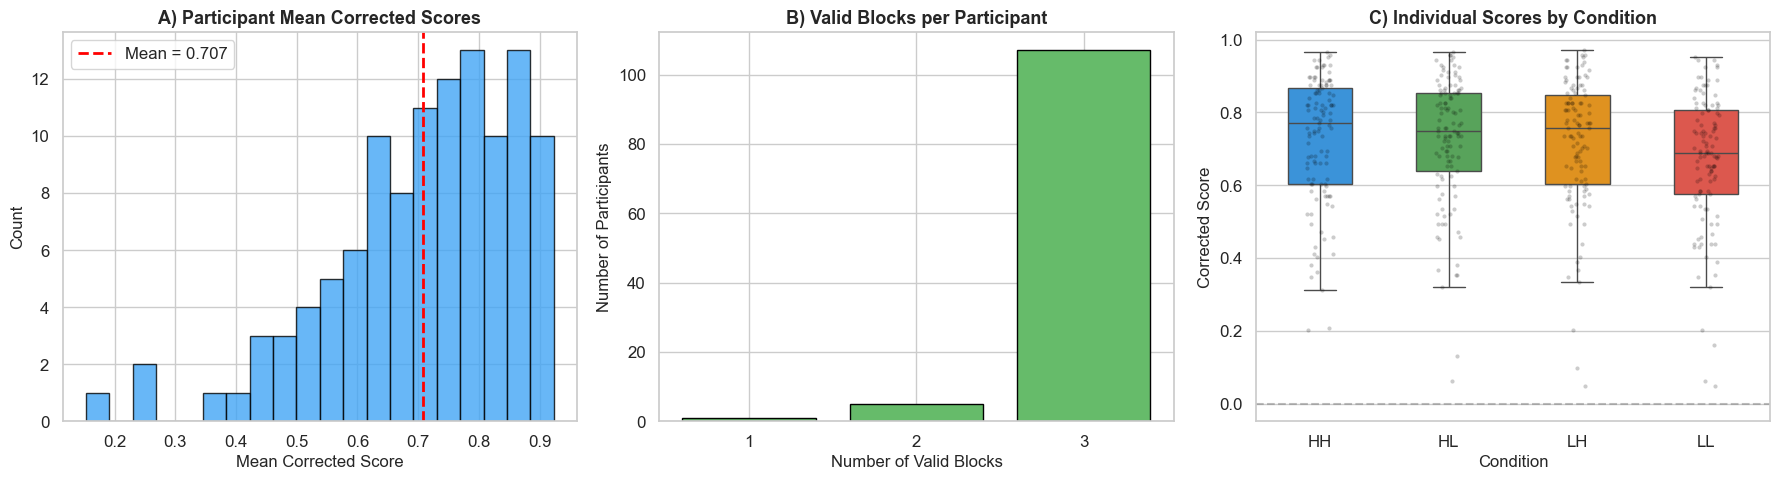

Potential outlier participants (mean ± 2SD): 5 of 113


,pid,mean_corrected_score
6,245,0.243056
46,299,0.250000
53,309,0.152778
92,371,0.347222
94,373,0.395833


In [46]:
# Overall participant accuracy
participant_overall = corrected_df.groupby('pid')['corrected_score'].mean().reset_index()
participant_overall.columns = ['pid', 'mean_corrected_score']

# Blocks retained per participant
blocks_retained = df_val[df_val['passes']].groupby('pid').size().reset_index(name='n_valid_blocks')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Distribution of mean corrected scores
ax = axes[0]
ax.hist(participant_overall['mean_corrected_score'], bins=20, color='#42A5F5', edgecolor='black', alpha=0.8)
ax.axvline(participant_overall['mean_corrected_score'].mean(), color='red', linestyle='--',
           linewidth=2, label=f"Mean = {participant_overall['mean_corrected_score'].mean():.3f}")
ax.set_xlabel('Mean Corrected Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('A) Participant Mean Corrected Scores', fontsize=13, fontweight='bold')
ax.legend()

# b) Blocks retained
ax = axes[1]
block_counts = blocks_retained['n_valid_blocks'].value_counts().sort_index()
ax.bar(block_counts.index, block_counts.values, color='#66BB6A', edgecolor='black')
ax.set_xlabel('Number of Valid Blocks', fontsize=12)
ax.set_ylabel('Number of Participants', fontsize=12)
ax.set_title('B) Valid Blocks per Participant', fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3])

# c) Corrected scores by condition (violin per participant)
ax = axes[2]
sns.boxplot(data=corrected_df, x='condition', y='corrected_score', order=cond_order,
            palette=palette, width=0.5, ax=ax, showfliers=False)
sns.stripplot(data=corrected_df, x='condition', y='corrected_score', order=cond_order,
              color='black', alpha=0.2, size=3, jitter=True, ax=ax)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Corrected Score', fontsize=12)
ax.set_title('C) Individual Scores by Condition', fontsize=13, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Flag potential outliers (|score| > 2SD from mean)
overall_mean = participant_overall['mean_corrected_score'].mean()
overall_std = participant_overall['mean_corrected_score'].std()
outliers = participant_overall[
    (participant_overall['mean_corrected_score'] < overall_mean - 2*overall_std) |
    (participant_overall['mean_corrected_score'] > overall_mean + 2*overall_std)
]
print(f"Potential outlier participants (mean ± 2SD): {len(outliers)} of {len(participant_overall)}")
if len(outliers) > 0:
    display(outliers)

## 16. Block-Level Analysis and Learning/Fatigue Effects

Examining whether performance changes across the 3 experimental blocks. A decline would suggest fatigue; an increase would suggest learning.

Overall Hit Rate by Block:
  Block 1: 0.8508 (1511/1776)
  Block 2: 0.8326 (1452/1744)
  Block 3: 0.8092 (1450/1792)

Friedman Test for Block Effect:
  χ²(2) = nan, p = nan
  ✗ No significant block effect


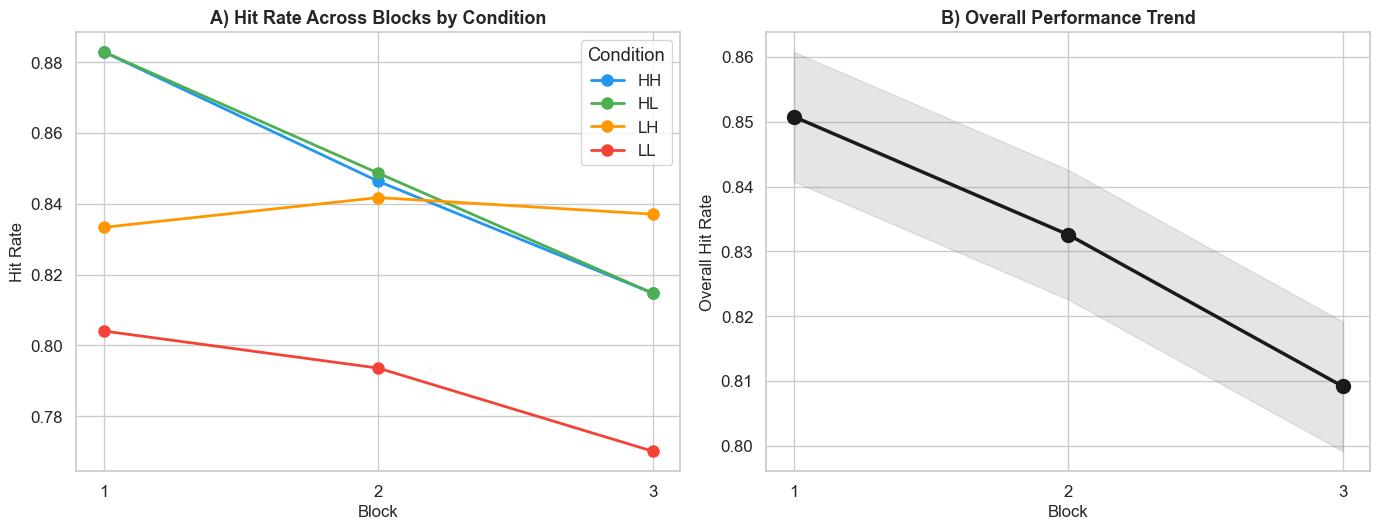

In [47]:
# Hit rate by block × condition
block_targets = targets_shown.copy()
block_tgt_count = block_targets.groupby(['block', 'condition']).size().reset_index(name='n_shown')

block_ir_hits = ir_cv.copy()  # ir_cv from cell above = IR pressed on repeats
block_hits = block_ir_hits.groupby(['block', 'condition'])['Accuracy IR'].sum().reset_index(name='hits')

block_df = block_tgt_count.merge(block_hits, on=['block', 'condition'], how='left')
block_df['hits'] = block_df['hits'].fillna(0)
block_df['hit_rate'] = block_df['hits'] / block_df['n_shown']

# Overall block hit rates
overall_block = block_targets.groupby('block').size().reset_index(name='n_shown')
overall_block_hits = block_ir_hits.groupby('block')['Accuracy IR'].sum().reset_index(name='hits')
overall_block = overall_block.merge(overall_block_hits, on='block', how='left')
overall_block['hit_rate'] = overall_block['hits'] / overall_block['n_shown']

print("Overall Hit Rate by Block:")
for _, row in overall_block.iterrows():
    print(f"  Block {int(row['block'])+1}: {row['hit_rate']:.4f} ({int(row['hits'])}/{int(row['n_shown'])})")

# Friedman test (repeated measures non-parametric)
# Need per-participant block scores
pid_block = ir_cv.groupby(['pid', 'block'])['Accuracy IR'].mean().reset_index()
pid_block_wide = pid_block.pivot(index='pid', columns='block', values='Accuracy IR').dropna()

if pid_block_wide.shape[1] == 3:
    fried_stat, fried_p = stats.friedmanchisquare(
        pid_block_wide[0], pid_block_wide[1], pid_block_wide[2])
    print(f"\nFriedman Test for Block Effect:")
    print(f"  χ²({2}) = {fried_stat:.4f}, p = {fried_p:.6f}")
    if fried_p < 0.05:
        print("  ★ Significant block effect detected")
    else:
        print("  ✗ No significant block effect")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
for cond in cond_order:
    sub = block_df[block_df['condition'] == cond]
    ax.plot(sub['block'] + 1, sub['hit_rate'], 'o-', label=cond, 
            color=palette[cond], linewidth=2, markersize=8)
ax.set_xlabel('Block', fontsize=12)
ax.set_ylabel('Hit Rate', fontsize=12)
ax.set_title('A) Hit Rate Across Blocks by Condition', fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.legend(title='Condition')

ax = axes[1]
ax.plot(overall_block['block'] + 1, overall_block['hit_rate'], 'ko-', 
        linewidth=2.5, markersize=10)
ax.fill_between(overall_block['block'] + 1, 
                overall_block['hit_rate'] - 0.01, 
                overall_block['hit_rate'] + 0.01, alpha=0.2, color='gray')
ax.set_xlabel('Block', fontsize=12)
ax.set_ylabel('Overall Hit Rate', fontsize=12)
ax.set_title('B) Overall Performance Trend', fontsize=13, fontweight='bold')
ax.set_xticks([1, 2, 3])

plt.tight_layout()
plt.show()

## 17. Exploratory: Signal Detection Analysis ($d'$ and Criterion $c$)

Signal Detection Theory provides a more nuanced separation of **sensitivity** ($d'$) from **response bias** ($c$):

$$d' = Z(\text{Hit Rate}) - Z(\text{FA Rate})$$
$$c = -0.5 \times [Z(\text{Hit Rate}) + Z(\text{FA Rate})]$$

Edge corrections: if Hit Rate = 1, replace with $1 - \frac{1}{2N}$; if FA Rate = 0, replace with $\frac{1}{2N}$.

Signal Detection Measures by Condition:


d_prime         criterion        
             mean     std      mean     std
condition                                  
HH         2.3759  0.6628    0.0642  0.3791
HL         2.3810  0.6585    0.0617  0.3923
LH         2.3346  0.6843    0.0848  0.3810
LL         2.1555  0.6560    0.1744  0.4164


Kruskal-Wallis on d': H(3) = 9.1713, p = 0.027098


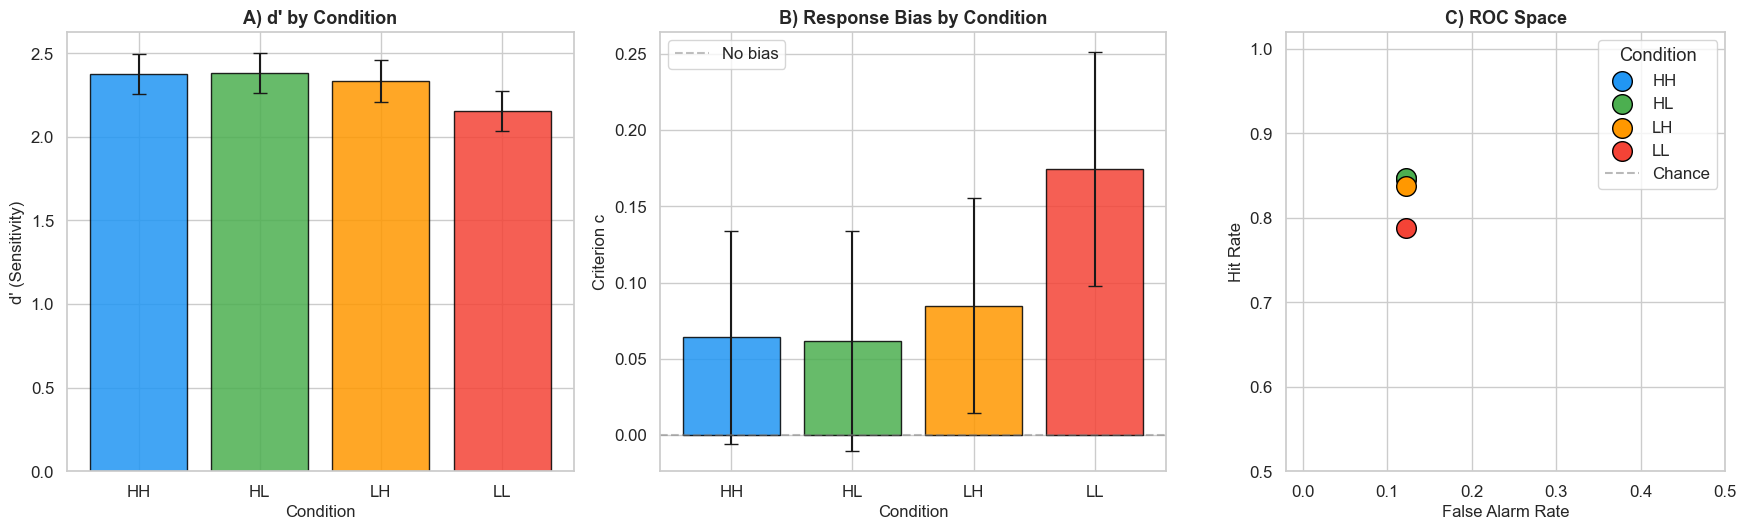

In [48]:
def compute_sdt(hit_rate, fa_rate, n_targets, n_lures):
    """Compute d' and c with edge corrections."""
    # Edge corrections (Macmillan & Creelman, 2005)
    hr = hit_rate
    far = fa_rate
    if hr == 1.0:
        hr = 1 - 1 / (2 * n_targets)
    if hr == 0.0:
        hr = 1 / (2 * n_targets)
    if far == 0.0:
        far = 1 / (2 * n_lures)
    if far == 1.0:
        far = 1 - 1 / (2 * n_lures)
    
    d_prime = norm.ppf(hr) - norm.ppf(far)
    criterion = -0.5 * (norm.ppf(hr) + norm.ppf(far))
    return d_prime, criterion

# Compute d' per participant × condition
sdt_records = []
for _, row in corrected_df.iterrows():
    n_tgt = row['n_targets']
    n_lure = fa_df[fa_df['pid'] == row['pid']]['n_nonrepeat'].values[0]
    dp, c = compute_sdt(row['hit_rate'], row['fa_rate'], n_tgt, n_lure)
    sdt_records.append({
        'pid': row['pid'], 'condition': row['condition'],
        'd_prime': dp, 'criterion': c,
        'hit_rate': row['hit_rate'], 'fa_rate': row['fa_rate']
    })

sdt_df = pd.DataFrame(sdt_records)

# Descriptive
print("Signal Detection Measures by Condition:")
sdt_summary = sdt_df.groupby('condition')[['d_prime', 'criterion']].agg(
    ['mean', 'std']).loc[cond_order].round(4)
display(sdt_summary)

# Kruskal-Wallis on d'
dp_groups = [sdt_df[sdt_df['condition'] == c]['d_prime'].values for c in cond_order]
kw_dp_stat, kw_dp_p = stats.kruskal(*dp_groups)
print(f"\nKruskal-Wallis on d': H({len(cond_order)-1}) = {kw_dp_stat:.4f}, p = {kw_dp_p:.6f}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# a) d' bar plot
ax = axes[0]
dp_means = sdt_df.groupby('condition')['d_prime'].agg(['mean', 'sem']).loc[cond_order]
ax.bar(cond_order, dp_means['mean'], yerr=dp_means['sem']*1.96, capsize=5,
       color=[palette[c] for c in cond_order], edgecolor='black', alpha=0.85)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel("d' (Sensitivity)", fontsize=12)
ax.set_title("A) d' by Condition", fontsize=13, fontweight='bold')

# b) Criterion bar plot
ax = axes[1]
c_means = sdt_df.groupby('condition')['criterion'].agg(['mean', 'sem']).loc[cond_order]
ax.bar(cond_order, c_means['mean'], yerr=c_means['sem']*1.96, capsize=5,
       color=[palette[c] for c in cond_order], edgecolor='black', alpha=0.85)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Criterion c', fontsize=12)
ax.set_title('B) Response Bias by Condition', fontsize=13, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='No bias')
ax.legend()

# c) ROC-space scatter
ax = axes[2]
cond_means = sdt_df.groupby('condition')[['fa_rate', 'hit_rate']].mean().loc[cond_order]
for cond in cond_order:
    ax.scatter(cond_means.loc[cond, 'fa_rate'], cond_means.loc[cond, 'hit_rate'],
               s=200, color=palette[cond], edgecolor='black', zorder=5, label=cond)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Chance')
ax.set_xlabel('False Alarm Rate', fontsize=12)
ax.set_ylabel('Hit Rate', fontsize=12)
ax.set_title('C) ROC Space', fontsize=13, fontweight='bold')
ax.set_xlim(-0.02, 0.5)
ax.set_ylim(0.5, 1.02)
ax.legend(title='Condition')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 17b. Exploratory: Reaction Time Analysis

Examining whether correct-hit reaction times differ across conditions — faster RTs may indicate stronger memory traces.

Reaction Time (ms) for Correct IR Hits by Condition:


,Mean,Median,SD,N
condition,,,,
HH,1725.3,1596.5,630.1,1126
HL,1711.8,1588.0,622.9,1127
LH,1660.9,1544.0,597.0,1112
LL,1761.0,1634.5,632.8,1048



Kruskal-Wallis on RT: H(3) = 14.8748, p = 0.001927


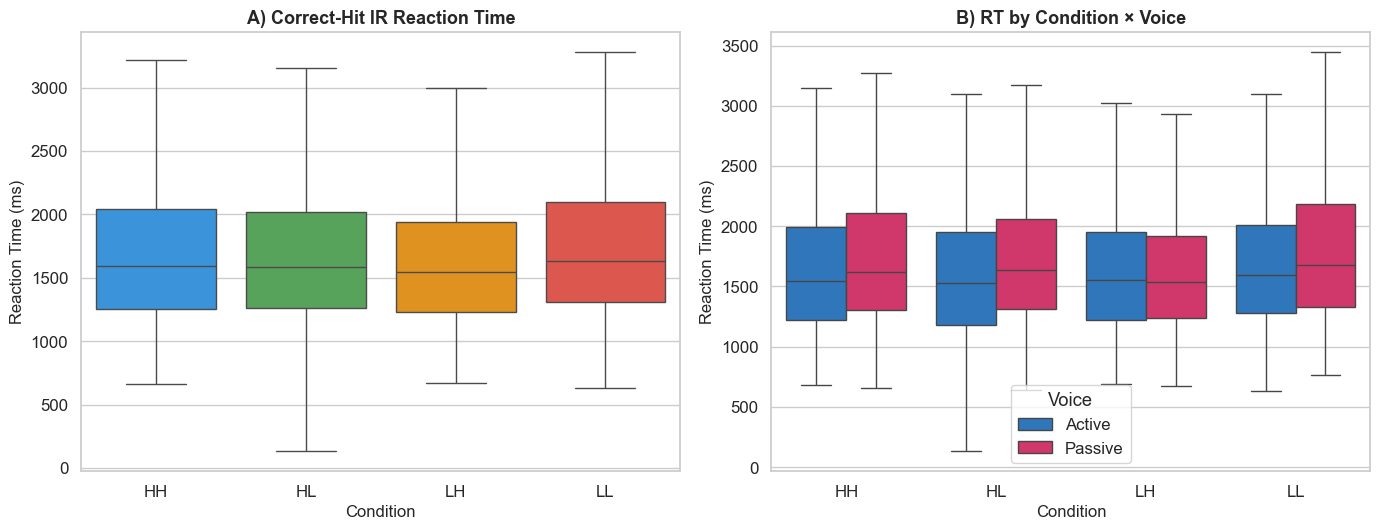

In [49]:
# Correct IR hits with reaction times
correct_ir = df_valid[(df_valid['Event'] == 'IR pressed') & 
                       df_valid['is_repeat'] & ~df_valid['is_validation'] &
                       (df_valid['Accuracy IR'] == 1)].copy()
correct_ir = correct_ir.dropna(subset=['Reaction_time_IR'])
correct_ir['condition'] = correct_ir['stim_prefix'].map(COND_MAP)
correct_ir = correct_ir.dropna(subset=['condition'])

# Descriptive
print("Reaction Time (ms) for Correct IR Hits by Condition:")
rt_summary = correct_ir.groupby('condition')['Reaction_time_IR'].agg(
    ['mean', 'median', 'std', 'count']).loc[cond_order]
rt_summary.columns = ['Mean', 'Median', 'SD', 'N']
display(rt_summary.round(1))

# Kruskal-Wallis on RT
rt_groups = [correct_ir[correct_ir['condition'] == c]['Reaction_time_IR'].values for c in cond_order]
kw_rt_stat, kw_rt_p = stats.kruskal(*rt_groups)
print(f"\nKruskal-Wallis on RT: H({len(cond_order)-1}) = {kw_rt_stat:.4f}, p = {kw_rt_p:.6f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
sns.boxplot(data=correct_ir, x='condition', y='Reaction_time_IR',
            order=cond_order, palette=palette, ax=ax, showfliers=False)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Reaction Time (ms)', fontsize=12)
ax.set_title('A) Correct-Hit IR Reaction Time', fontsize=13, fontweight='bold')

ax = axes[1]
correct_ir['voice_label'] = correct_ir['voice'].map({'A': 'Active', 'P': 'Passive'})
sns.boxplot(data=correct_ir, x='condition', y='Reaction_time_IR', hue='voice_label',
            order=cond_order, hue_order=['Active', 'Passive'],
            palette=voice_palette, ax=ax, showfliers=False)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Reaction Time (ms)', fontsize=12)
ax.set_title('B) RT by Condition × Voice', fontsize=13, fontweight='bold')
ax.legend(title='Voice')

plt.tight_layout()
plt.show()

## 17c. Repeated-Question Statistics by Condition (HH, HL, LH, LL)

Mapping the stimulus prefixes with the verb indicator to four memorability conditions:

| Stimulus Prefix | Mapped Condition | Meaning |
|---|---|---|
| `HH` (HVH) | **HH** | High Subject × High Object |
| `HVL` | **HL** | High Subject × Low Object |
| `LVH` | **LH** | Low Subject × High Object |
| `LVL` | **LL** | Low Subject × Low Object |

This section focuses on the **repeated (second) presentations** of target sentences, examining recognition performance broken down by these four conditions.

REPEATED-QUESTION PERFORMANCE BY CONDITION  (HVH→HH, HVL→HL, LVH→LH, LVL→LL)
Miss = repeat sentence shown but participant did NOT press Spacebar (no IR)


,Repeat Shown,IR Presses,Correct Hits,Misses (No IR),Hit Rate,Miss Rate,Mean RT (ms),Median RT (ms),SD RT (ms)
Condition,,,,,,,,,
HH,1328,1126,1126,202,0.8479,0.1521,1725.3135,1596.5,630.0944
HL,1328,1127,1127,201,0.8486,0.1514,1711.8492,1588.0,622.9200
LH,1328,1112,1112,216,0.8373,0.1627,1660.9272,1544.0,597.0454
LL,1328,1048,1048,280,0.7892,0.2108,1761.0019,1634.5,632.7911



Per-Participant Repeat Hit Rates by Condition:


,Mean,Median,SD,SE,N,95% CI Lower,95% CI Upper
condition,,,,,,,
HH,0.8459,0.9167,0.1674,0.0157,113,0.8150,0.8767
HL,0.8466,0.9167,0.1745,0.0164,113,0.8144,0.8788
LH,0.8374,0.9167,0.1728,0.0163,113,0.8055,0.8692
LL,0.7876,0.8333,0.1885,0.0177,113,0.7529,0.8224



Per-Participant Repeat Miss Rates by Condition:


,Mean,Median,SD,SE,N
condition,,,,,
HH,0.1541,0.0833,0.1674,0.0157,113
HL,0.1534,0.0833,0.1745,0.0164,113
LH,0.1626,0.0833,0.1728,0.0163,113
LL,0.2124,0.1667,0.1885,0.0177,113



Kruskal-Wallis Test on Repeat Hit Rate:
  H(3) = 11.3185,  p = 0.010123
  Effect size η²_H = 0.0186
  ★ SIGNIFICANT at α = 0.05  →  Repeat recognition differs across conditions.

  Dunn's Post-Hoc (Bonferroni) on Repeat Hit Rate:


,HH,HL,LH,LL
HH,1.000000,1.00000,1.000000,0.031001
HL,1.000000,1.00000,1.000000,0.017130
LH,1.000000,1.00000,1.000000,0.149513
LL,0.031001,0.01713,0.149513,1.000000


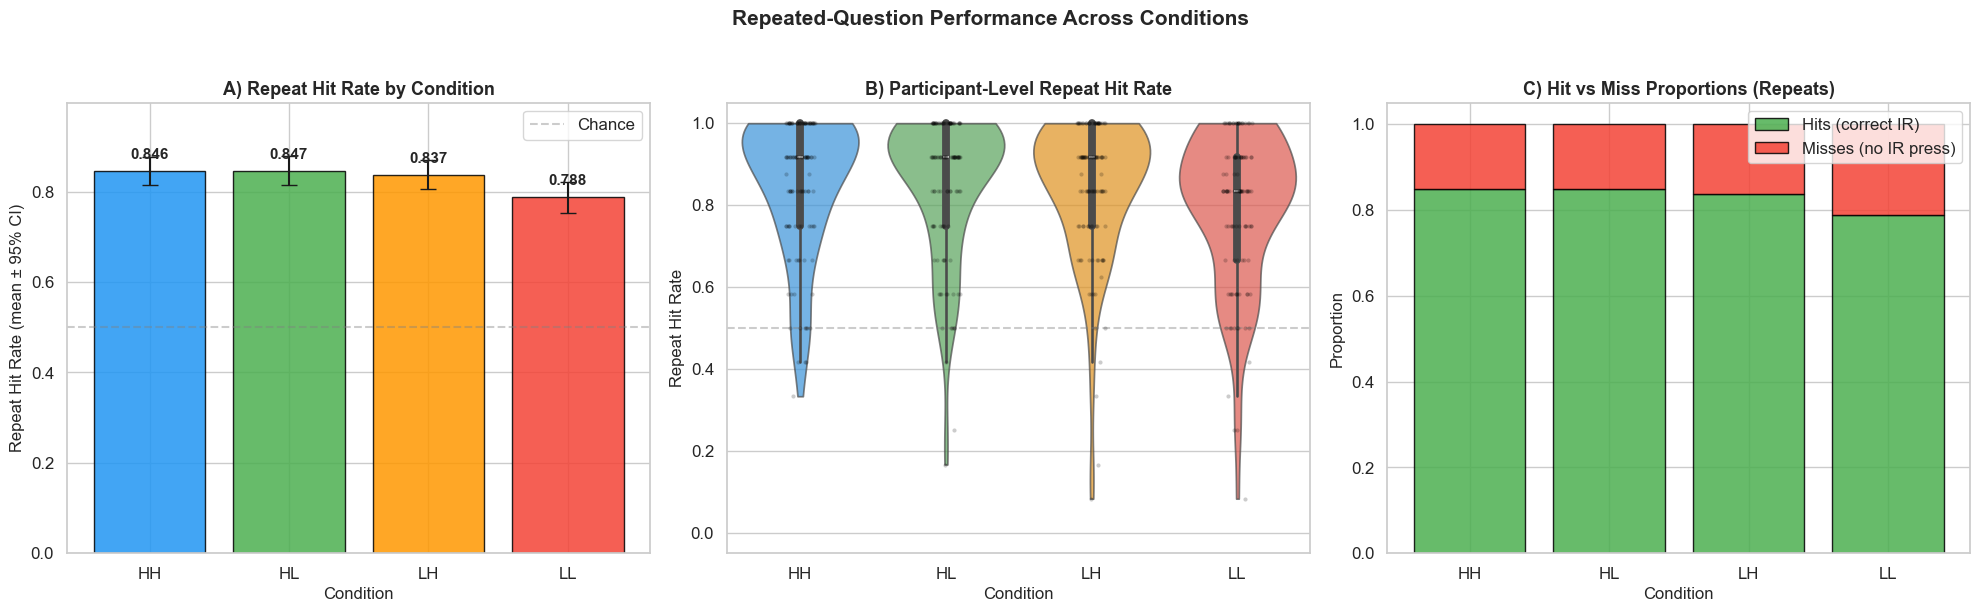

In [52]:
# ── Repeated-Question Statistics by 4 Conditions ──────────────────────────────
palette = {'HH': '#2196F3', 'HL': '#4CAF50', 'LH': '#FF9800', 'LL': '#F44336'}

# Filter to repeat presentations of target sentences (non-validation) in valid blocks
repeat_shown = df_valid[
    (df_valid['Event'] == 'Sentence shown') &
    df_valid['is_repeat'] &
    ~df_valid['is_validation']
].copy()
repeat_shown['condition'] = repeat_shown['stim_prefix'].map(COND_MAP)
repeat_shown = repeat_shown.dropna(subset=['condition'])

# IR responses on repeats (any IR press, regardless of accuracy)
repeat_ir = df_valid[
    (df_valid['Event'] == 'IR pressed') &
    df_valid['is_repeat'] &
    ~df_valid['is_validation']
].copy()
repeat_ir['condition'] = repeat_ir['stim_prefix'].map(COND_MAP)
repeat_ir = repeat_ir.dropna(subset=['condition'])

# ── Per-condition aggregate stats ─────────────────────────────────────────────
# Misses = Repeat sentences shown – IR presses on those repeats
# (i.e., participant did NOT press Spacebar at all on a repeated sentence)
repeat_stats_list = []
for cond in cond_order:
    shown = repeat_shown[repeat_shown['condition'] == cond]
    ir_all = repeat_ir[repeat_ir['condition'] == cond]
    hits  = ir_all[ir_all['Accuracy IR'] == 1]

    n_shown = len(shown)
    n_ir    = len(ir_all)       # total IR presses (hits)
    n_hits  = len(hits)         # correct IR presses
    n_miss  = n_shown - n_ir    # no IR press at all → miss
    hit_rate  = n_hits / n_shown if n_shown > 0 else 0
    miss_rate = n_miss / n_shown if n_shown > 0 else 0

    # RT for correct hits
    rt_vals = hits['Reaction_time_IR'].dropna()
    mean_rt = rt_vals.mean() if len(rt_vals) > 0 else np.nan
    median_rt = rt_vals.median() if len(rt_vals) > 0 else np.nan
    sd_rt = rt_vals.std() if len(rt_vals) > 0 else np.nan

    repeat_stats_list.append({
        'Condition': cond,
        'Repeat Shown': n_shown,
        'IR Presses': n_ir,
        'Correct Hits': n_hits,
        'Misses (No IR)': n_miss,
        'Hit Rate': hit_rate,
        'Miss Rate': miss_rate,
        'Mean RT (ms)': mean_rt,
        'Median RT (ms)': median_rt,
        'SD RT (ms)': sd_rt,
    })

repeat_stats_table = pd.DataFrame(repeat_stats_list).set_index('Condition').loc[cond_order]

print("=" * 80)
print("REPEATED-QUESTION PERFORMANCE BY CONDITION  (HVH→HH, HVL→HL, LVH→LH, LVL→LL)")
print("=" * 80)
print("Miss = repeat sentence shown but participant did NOT press Spacebar (no IR)")
display(repeat_stats_table.round(4))

# ── Per-participant × condition repeat hit rate ───────────────────────────────
rpt_per_pc = repeat_shown.groupby(['pid', 'condition']).size().reset_index(name='n_shown')
rpt_ir_pc = repeat_ir.groupby(['pid', 'condition']).size().reset_index(name='n_ir')
rpt_hits_pc = repeat_ir[repeat_ir['Accuracy IR'] == 1].groupby(
    ['pid', 'condition']).size().reset_index(name='n_hits')

rpt_pc = rpt_per_pc.merge(rpt_ir_pc, on=['pid', 'condition'], how='left')
rpt_pc = rpt_pc.merge(rpt_hits_pc, on=['pid', 'condition'], how='left')
rpt_pc['n_ir'] = rpt_pc['n_ir'].fillna(0)
rpt_pc['n_hits'] = rpt_pc['n_hits'].fillna(0)
rpt_pc['hit_rate'] = rpt_pc['n_hits'] / rpt_pc['n_shown']
rpt_pc['miss_rate'] = (rpt_pc['n_shown'] - rpt_pc['n_ir']) / rpt_pc['n_shown']

repeat_desc = rpt_pc.groupby('condition')['hit_rate'].agg(
    Mean='mean', Median='median', SD='std',
    SE=lambda x: x.std() / np.sqrt(len(x)), N='count'
).loc[cond_order]
repeat_desc['95% CI Lower'] = repeat_desc['Mean'] - 1.96 * repeat_desc['SE']
repeat_desc['95% CI Upper'] = repeat_desc['Mean'] + 1.96 * repeat_desc['SE']

miss_desc = rpt_pc.groupby('condition')['miss_rate'].agg(
    Mean='mean', Median='median', SD='std',
    SE=lambda x: x.std() / np.sqrt(len(x)), N='count'
).loc[cond_order]

print("\nPer-Participant Repeat Hit Rates by Condition:")
display(repeat_desc.round(4))

print("\nPer-Participant Repeat Miss Rates by Condition:")
display(miss_desc.round(4))

# ── Kruskal-Wallis on repeat hit rate ─────────────────────────────────────────
rpt_groups = [rpt_pc[rpt_pc['condition'] == c]['hit_rate'].values for c in cond_order]
kw_rpt_stat, kw_rpt_p = stats.kruskal(*rpt_groups)
n_rpt_total = sum(len(g) for g in rpt_groups)
eta_sq_rpt = (kw_rpt_stat - len(rpt_groups) + 1) / (n_rpt_total - len(rpt_groups))

print(f"\nKruskal-Wallis Test on Repeat Hit Rate:")
print(f"  H({len(cond_order)-1}) = {kw_rpt_stat:.4f},  p = {kw_rpt_p:.6f}")
print(f"  Effect size η²_H = {eta_sq_rpt:.4f}")
if kw_rpt_p < 0.05:
    print("  ★ SIGNIFICANT at α = 0.05  →  Repeat recognition differs across conditions.")
    # Dunn's post-hoc
    dunn_rpt = sp.posthoc_dunn(rpt_pc, val_col='hit_rate',
                                group_col='condition', p_adjust='bonferroni')
    dunn_rpt = dunn_rpt.loc[cond_order, cond_order]
    print("\n  Dunn's Post-Hoc (Bonferroni) on Repeat Hit Rate:")
    display(dunn_rpt.round(6))
else:
    print("  ✗ NOT significant at α = 0.05")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (A) Bar chart: repeat hit rate by condition with 95% CI
ax = axes[0]
means = repeat_desc['Mean']
ci_err = 1.96 * repeat_desc['SE']
bars = ax.bar(cond_order, means, yerr=ci_err, capsize=6,
              color=[palette[c] for c in cond_order], edgecolor='black', alpha=0.85)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{m:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Repeat Hit Rate (mean ± 95% CI)', fontsize=12)
ax.set_title('A) Repeat Hit Rate by Condition', fontsize=13, fontweight='bold')
ax.set_ylim(0, min(1.0, means.max() + 0.15))
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Chance')
ax.legend()

# (B) Violin + strip: per-participant repeat hit rate
ax = axes[1]
sns.violinplot(data=rpt_pc, x='condition', y='hit_rate', order=cond_order,
               palette=palette, inner='box', alpha=0.7, ax=ax, cut=0)
sns.stripplot(data=rpt_pc, x='condition', y='hit_rate', order=cond_order,
              color='black', alpha=0.2, size=3, jitter=True, ax=ax)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Repeat Hit Rate', fontsize=12)
ax.set_title('B) Participant-Level Repeat Hit Rate', fontsize=13, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)

# (C) Stacked bar: Hits vs Misses proportion
ax = axes[2]
hit_rates_agg = repeat_stats_table['Hit Rate']
miss_rates_agg = repeat_stats_table['Miss Rate']
other_rates = 1 - hit_rates_agg - miss_rates_agg
x_pos = range(len(cond_order))
ax.bar(x_pos, hit_rates_agg, color='#4CAF50', edgecolor='black', label='Hits (correct IR)', alpha=0.85)
ax.bar(x_pos, miss_rates_agg, bottom=hit_rates_agg, color='#F44336', edgecolor='black',
       label='Misses (no IR press)', alpha=0.85)
if (other_rates > 0.001).any():
    ax.bar(x_pos, other_rates, bottom=hit_rates_agg + miss_rates_agg,
           color='#9E9E9E', edgecolor='black', label='Other (IR but wrong)', alpha=0.6)
ax.set_xticks(x_pos)
ax.set_xticklabels(cond_order)
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('C) Hit vs Miss Proportions (Repeats)', fontsize=13, fontweight='bold')
ax.legend()

plt.suptitle('Repeated-Question Performance Across Conditions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 18. Summary of Findings and Hypothesis Evaluation

In [51]:
# Build summary table
summary_data = {
    'Hypothesis': [
        'H1: HH > LL (noun memorability effect)',
        'H2: HL, LH between HH and LL (composition)',
        'H3: Voice affects memorability',
        'Exploratory: Condition × Voice interaction',
        'Exploratory: d\' differs by condition',
        'Exploratory: RT differs by condition',
    ],
    'Test': [
        f'Kruskal-Wallis + Dunn (Bonferroni)',
        f'Dunn post-hoc pairwise',
        f'Mann-Whitney U',
        f'Kruskal-Wallis (8 groups)',
        f'Kruskal-Wallis on d\'',
        f'Kruskal-Wallis on RT',
    ],
    'Statistic': [
        f'H(3) = {kw_stat:.2f}',
        f'See post-hoc table',
        f'U = {mw_stat:.1f}',
        f'H(7) = {kw8_stat:.2f}',
        f'H(3) = {kw_dp_stat:.2f}',
        f'H(3) = {kw_rt_stat:.2f}',
    ],
    'p-value': [
        f'{kw_p:.4f}',
        f'HH-LL: {dunn_bonf.loc["HH","LL"]:.4f}',
        f'{mw_p:.4f}',
        f'{kw8_p:.4f}',
        f'{kw_dp_p:.4f}',
        f'{kw_rt_p:.4f}',
    ],
    'Effect Size': [
        f'η²_H = {eta_sq:.4f}',
        '—',
        f'r = {rank_biserial:.4f}',
        '—',
        '—',
        '—',
    ],
    'Supported?': [
        '✓ Yes' if kw_p < 0.05 else '✗ No',
        '✓ Partially' if dunn_bonf.loc['HH','LL'] < 0.05 else '✗ No',
        '✓ Yes' if mw_p < 0.05 else '✗ No',
        '✓ Yes' if kw8_p < 0.05 else '✗ No',
        '✓ Yes' if kw_dp_p < 0.05 else '✗ No',
        '✓ Yes' if kw_rt_p < 0.05 else '✗ No',
    ]
}

df_summary = pd.DataFrame(summary_data)
print("=" * 80)
print("SUMMARY OF STATISTICAL FINDINGS")
print("=" * 80)
display(df_summary)

SUMMARY OF STATISTICAL FINDINGS


,Hypothesis,Test,Statistic,p-value,Effect Size,Supported?
0,H1: HH > LL (noun memorability effect),Kruskal-Wallis + Dunn (Bonferroni),H(3) = 10.00,0.0186,η²_H = 0.0156,✓ Yes
1,"H2: HL, LH between HH and LL (composition)",Dunn post-hoc pairwise,See post-hoc table,HH-LL: 0.0408,—,✓ Partially
2,H3: Voice affects memorability,Mann-Whitney U,U = 6055.5,0.5038,r = 0.0515,✗ No
3,Exploratory: Condition × Voice interaction,Kruskal-Wallis (8 groups),H(7) = 14.03,0.0506,—,✗ No
4,Exploratory: d' differs by condition,Kruskal-Wallis on d',H(3) = 9.17,0.0271,—,✓ Yes
5,Exploratory: RT differs by condition,Kruskal-Wallis on RT,H(3) = 14.87,0.0019,—,✓ Yes
